In [1]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn simpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

In [3]:
np.random.seed(42)

start_date = datetime(2023,1,1)
days = 730

warehouses = [f"WH{i}" for i in range(1,11)]
products = [f"P{i}" for i in range(1,21)]

data = []

for day in range(days):
    date = start_date + timedelta(days=day)

    for w in warehouses:
        for p in products:

            base_demand = np.random.randint(20,50)

            if date.weekday() >= 5:
                base_demand *= 1.2

            promotion = np.random.choice([0,1], p=[0.9,0.1])

            if promotion:
                base_demand *= 1.5

            sales = int(base_demand + np.random.normal(0,5))

            data.append([
                date,
                w,
                p,
                max(sales,0),
                promotion,
                int(date.month==12)
            ])

df = pd.DataFrame(
    data,
    columns=[
        "date",
        "warehouse_id",
        "product_id",
        "sales",
        "promotion",
        "holiday"
    ]
)

df.head()

,date,warehouse_id,product_id,sales,promotion,holiday
0,2023-01-01,WH1,P1,33,0,0
1,2023-01-01,WH1,P2,44,0,0
2,2023-01-01,WH1,P3,35,0,0
3,2023-01-01,WH1,P4,29,0,0
4,2023-01-01,WH1,P5,50,0,0


In [4]:
df.shape

(146000, 6)

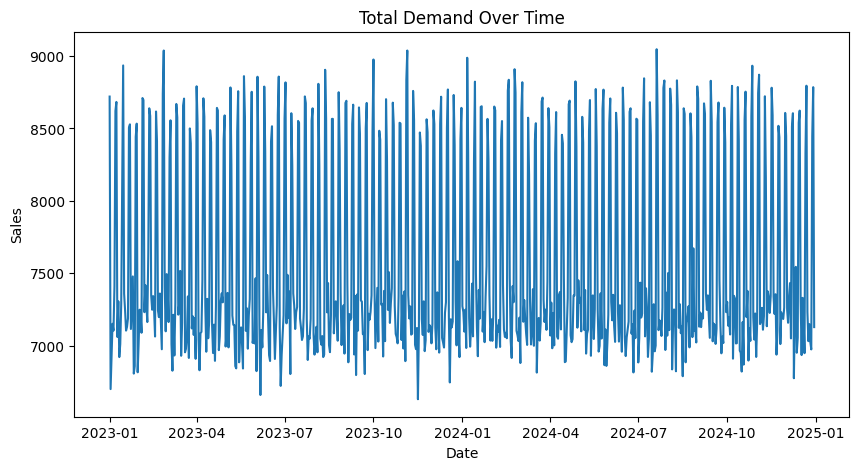

In [5]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Total Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [6]:
df["date"] = pd.to_datetime(df["date"])

df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["week_of_year"] = df["date"].dt.isocalendar().week

In [7]:
df = df.sort_values(["warehouse_id", "product_id", "date"])

In [8]:
df["lag_1"] = df.groupby(
    ["warehouse_id","product_id"]
)["sales"].shift(1)

df["lag_7"] = df.groupby(
    ["warehouse_id","product_id"]
)["sales"].shift(7)

In [9]:
df["rolling_mean_7"] = df.groupby(
    ["warehouse_id","product_id"]
)["sales"].transform(
    lambda x: x.shift(1).rolling(7).mean()
)

df["rolling_std_7"] = df.groupby(
    ["warehouse_id","product_id"]
)["sales"].transform(
    lambda x: x.shift(1).rolling(7).std()
)

In [10]:
df = df.dropna()

In [11]:
df.head()

,date,warehouse_id,product_id,sales,promotion,holiday,day_of_week,month,year,week_of_year,lag_1,lag_7,rolling_mean_7,rolling_std_7
1400,2023-01-08,WH1,P1,36,0,0,6,1,2023,1,24.0,33.0,33.000000,11.986103
1600,2023-01-09,WH1,P1,24,0,0,0,1,2023,2,36.0,19.0,33.428571,12.039617
1800,2023-01-10,WH1,P1,29,0,0,1,1,2023,2,24.0,47.0,34.142857,11.156890
2000,2023-01-11,WH1,P1,50,0,0,2,1,2023,2,29.0,47.0,31.571429,9.675694
2200,2023-01-12,WH1,P1,45,0,0,3,1,2023,2,50.0,21.0,32.000000,10.503968


In [12]:
features = [
    "promotion",
    "holiday",
    "day_of_week",
    "month",
    "week_of_year",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7"
]

target = "sales"

X = df[features]
y = df[target]

In [13]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.248445544348824
RMSE: 11.161315494187427


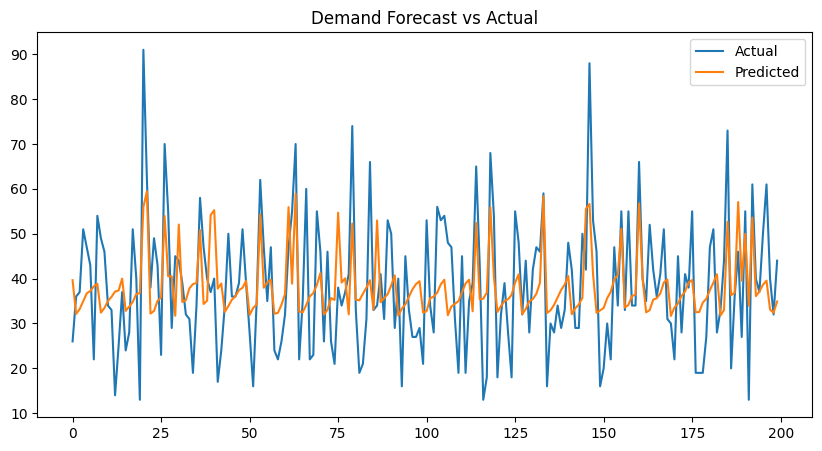

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(predictions[:200], label="Predicted")

plt.legend()
plt.title("Demand Forecast vs Actual")
plt.show()

In [17]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

In [18]:
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 9.121511459350586
XGBoost RMSE: 10.983185835346227


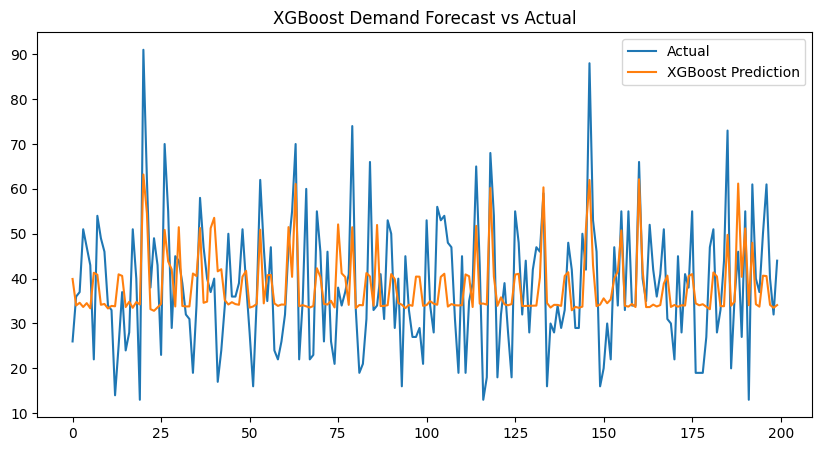

In [19]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(xgb_predictions[:200], label="XGBoost Prediction")

plt.legend()
plt.title("XGBoost Demand Forecast vs Actual")
plt.show()

In [20]:
!pip install tensorflow

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [21]:
series_df = df[
    (df["warehouse_id"] == "WH1") &
    (df["product_id"] == "P1")
].copy()

series_df = series_df.sort_values("date")

series_df[["date","sales"]].head()

,date,sales
1400,2023-01-08,36
1600,2023-01-09,24
1800,2023-01-10,29
2000,2023-01-11,50
2200,2023-01-12,45


In [22]:
scaler = MinMaxScaler()

sales_values = series_df["sales"].values.reshape(-1,1)

scaled_sales = scaler.fit_transform(sales_values)

In [23]:
sequence_length = 7

X_seq = []
y_seq = []

for i in range(sequence_length, len(scaled_sales)):

    X_seq.append(scaled_sales[i-sequence_length:i])
    y_seq.append(scaled_sales[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Input shape:", X_seq.shape)

Input shape: (716, 7, 1)


In [24]:
split = int(len(X_seq)*0.8)

X_train_lstm = X_seq[:split]
X_test_lstm = X_seq[split:]

y_train_lstm = y_seq[:split]
y_test_lstm = y_seq[split:]

In [25]:
model_lstm = Sequential()

model_lstm.add(
    LSTM(
        units=50,
        activation="relu",
        input_shape=(7,1)
    )
)

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - loss: 0.1621 - val_loss: 0.0725
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0703 - val_loss: 0.0188
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0326 - val_loss: 0.0189
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0261 - val_loss: 0.0188
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0275 - val_loss: 0.0190
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0269 - val_loss: 0.0187
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0264 - val_loss: 0.0187
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0288 - val_loss: 0.0187
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0280 - val_loss: 0.0189
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0274 - val_loss: 0.0187


In [27]:
lstm_predictions = model_lstm.predict(X_test_lstm)

lstm_predictions = scaler.inverse_transform(lstm_predictions)

y_test_actual = scaler.inverse_transform(y_test_lstm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [28]:
mae_lstm = mean_absolute_error(y_test_actual, lstm_predictions)

rmse_lstm = np.sqrt(
    mean_squared_error(y_test_actual, lstm_predictions)
)

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 10.660288307401869
LSTM RMSE: 13.431519189035901


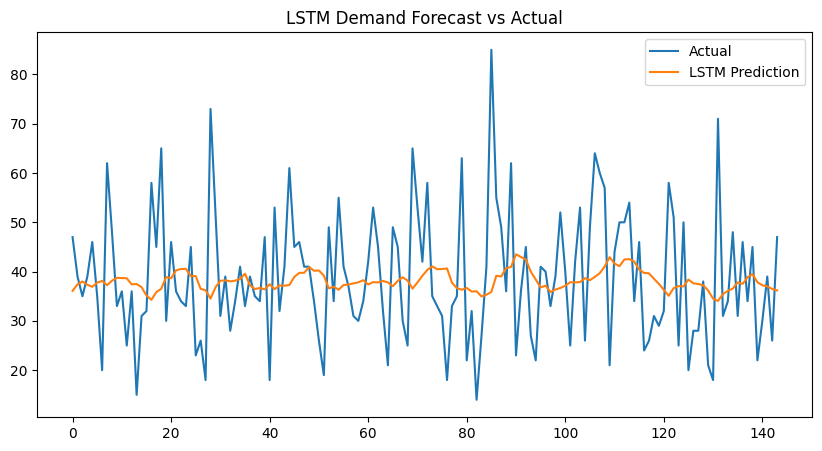

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label="Actual")
plt.plot(lstm_predictions[:200], label="LSTM Prediction")

plt.legend()
plt.title("LSTM Demand Forecast vs Actual")

plt.show()

In [30]:
results = pd.DataFrame({
    "Model": ["Linear Regression","XGBoost","LSTM"],
    "MAE": [mae, mae_xgb, mae_lstm],
    "RMSE": [rmse, rmse_xgb, rmse_lstm]
})

results

,Model,MAE,RMSE
0,Linear Regression,9.248446,11.161315
1,XGBoost,9.121511,10.983186
2,LSTM,10.660288,13.431519


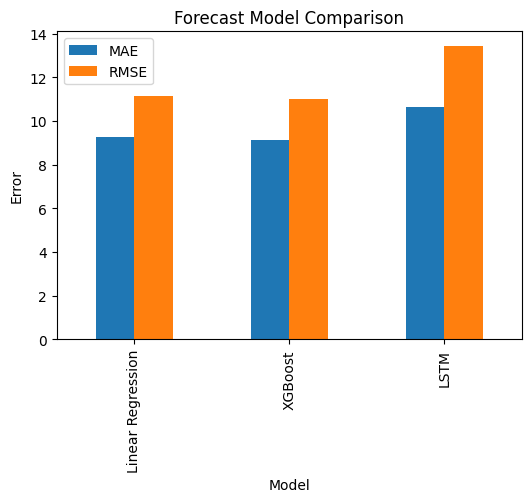

In [31]:
results.set_index("Model").plot(kind="bar", figsize=(6,4))

plt.title("Forecast Model Comparison")
plt.ylabel("Error")

plt.show()

In [32]:
best_model_name = results.sort_values("MAE").iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: XGBoost


In [33]:
import joblib

if best_model_name == "Linear Regression":
    best_model = model

elif best_model_name == "XGBoost":
    best_model = xgb_model

else:
    best_model = model_lstm

In [34]:
joblib.dump(best_model, "best_demand_forecast_model.pkl")

['best_demand_forecast_model.pkl']